In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

<h1>CUP - KNN</h1>
<p>Exploring the cup dataset with KNN Classifier.</p>
<hr/>

In [2]:
import importlib

from sympy import false

import cross_common as cr
import cup_common as cc
import knn_common as kc
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor


In [3]:
importlib.reload(cc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
# The common fold strategy used trough all models
outer_cv = cr.common_fold_strategy(False)
default_krange = list(range(1, 41, 2)) # <-- it means [1, 3, 5,..., 41]
default_metric = "mae"
common_scoring = cr.common_scoring(default_metric)
scaler = StandardScaler()

default_pipe = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsRegressor())
])

default_param_grid = {
    "model__n_neighbors": default_krange,
    "model__weights": ["uniform"],
    "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    "model__metric": ["minkowski"]
}


<h3>Data Loading</h3>

In [5]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [6]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [7]:
importlib.reload(cr)

gs = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=common_scoring,
    cv=outer_cv,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_base_model, best_base_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 20  splits: 5
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 21, 'model__p': 2, 'model__weights': 'uniform'}
Best score: -9.703986167907715
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=21))])


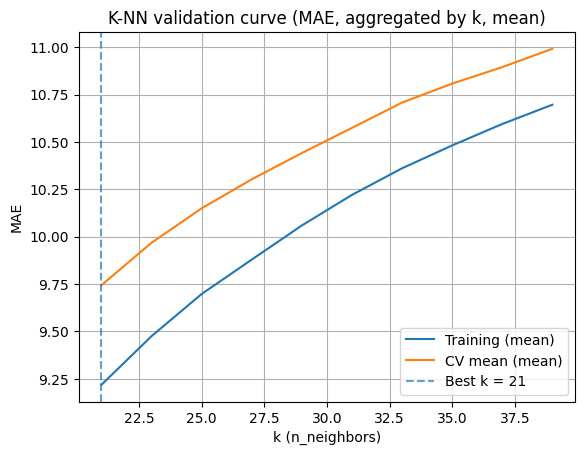

In [8]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs,"mean")

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>
<p>With distance-weighted KNN, the training error might be zero by construction, as each training point dominates its own prediction. Therefore, only the validation curve provides meaningful information about generalization.</p>

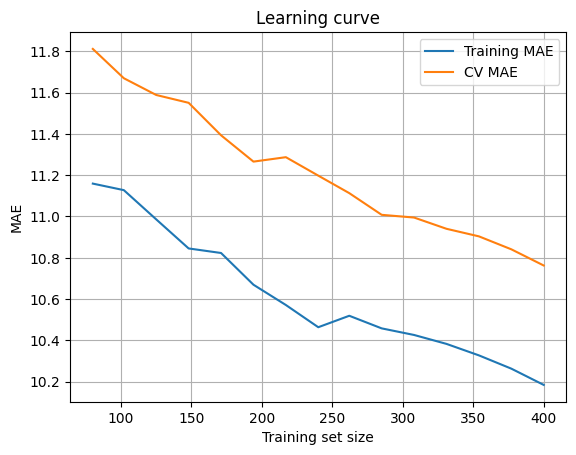

In [9]:
importlib.reload(cr)
cr.plot_learning_curve(best_base_model, X_tr, y_tr, outer_cv, scoring=common_scoring)

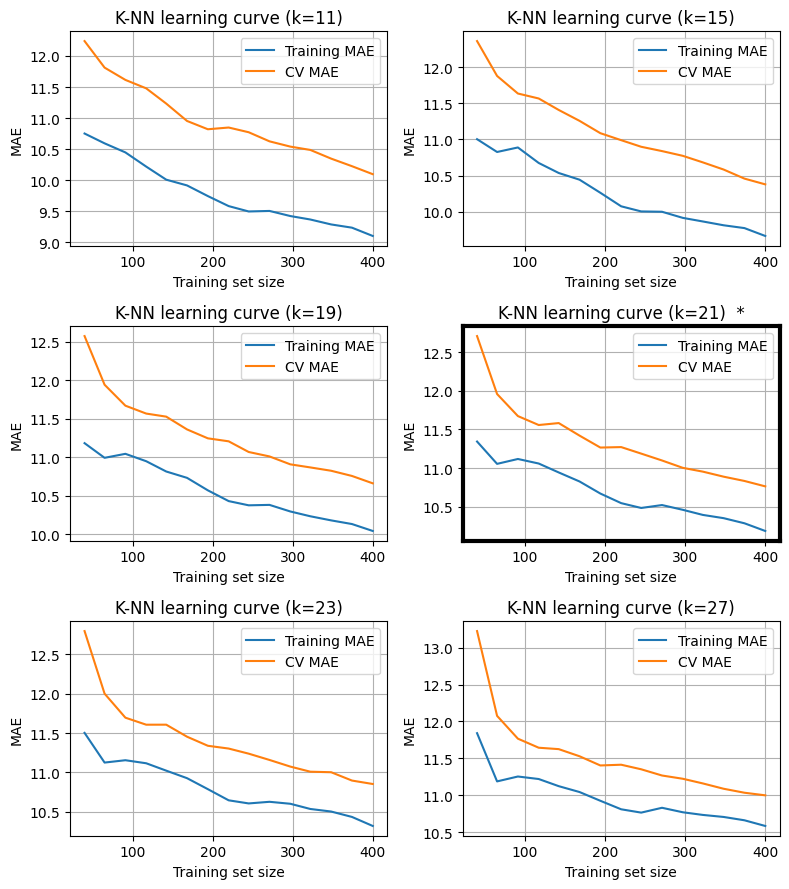

In [10]:
importlib.reload(kc)
kc.plot_knn_learning_curves_grid(
    best_base_model,
    X=X_tr,
    y=y_tr,
    cv=outer_cv,
    score_correction=-1,
    scoring=common_scoring
)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [11]:
from sklearn import clone
runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
non_nested_result = cr.kfold(runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 149.0456
Validation RMSE | 12.2084
Validation MEE  | 21.8815
Validation MAE  | 9.9320
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 144.8075
Validation RMSE | 12.0336
Validation MEE  | 21.3237
Validation MAE  | 9.6649
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 132.2841
Validation RMSE | 11.5015
Validation MEE  | 20.8085
Validation MAE  | 9.3222
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 4, train size: 400, val size: 100
 
Fold sum

In [12]:
#cr.kfold_regression_table(non_nested_result, use="mae", derive_rmse=True)

<p>Comparing the metrics obtained from grid search with the one originating from kfold function. They must match almost exaclty apart from sign which depends on the scoring function.</p>

In [13]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -9.7040 ± 0.3737
Best CV func score: 9.7040 ± 0.3737


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=common_scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 20  splits: 3
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 21, 'model__p': 2, 'model__weights': 'uniform'}
Best score: -10.376038551330566
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=21))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 149.0456
Validation RMSE | 12.2084
Validation MEE  | 21.8815
Validation MAE  | 9.9320
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 20  splits: 3
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 21, 'model__p': 2, 'model__weights': 'uniform'}
Best score: -10.520183245340982
Best model: Pipeline(steps=[('scaler', St

In [15]:
cr.kfold_regression_table(nested_result, use="mae", derive_rmse=True)

,TR_MAE,VL_MAE,Gap(TR-VL),TR_RMSE,VL_RMSE
Fold,,,,,
1,9.142465,9.932027,0.789562,3.023651,3.151512
2,9.153822,9.664863,0.511041,3.025528,3.108836
3,9.244488,9.322193,0.077705,3.040475,3.053227
4,8.978835,10.290485,1.311650,2.996470,3.207879
5,9.460995,9.310363,-0.150632,3.075873,3.051289
MEAN,9.196121,9.703986,0.507865,3.032400,3.114548
STD,0.176337,0.417798,0.579674,0.029025,0.066842


<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

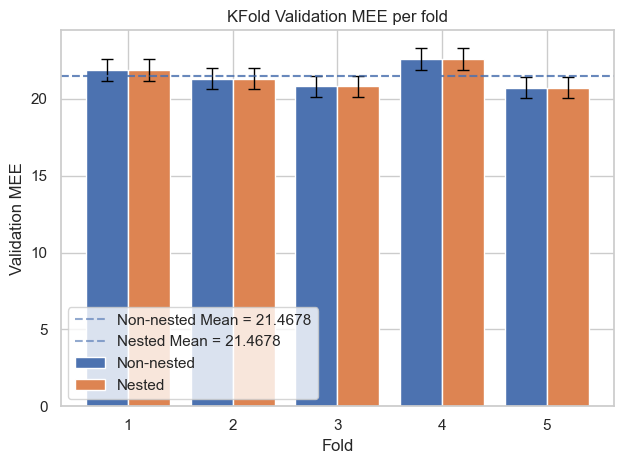

In [16]:
importlib.reload(cr)
cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], "mee")

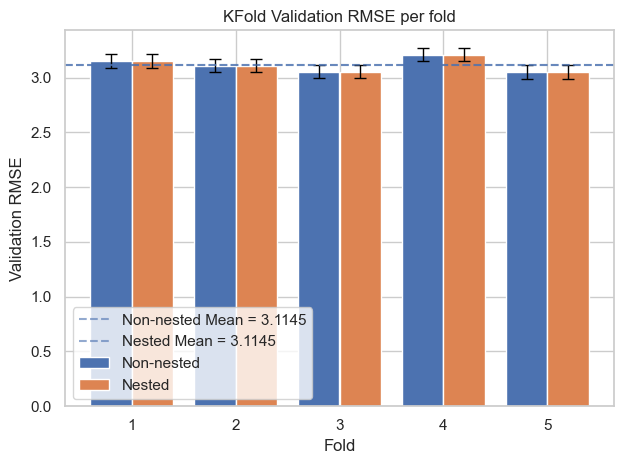

In [17]:
importlib.reload(cr)
cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], "rmse")

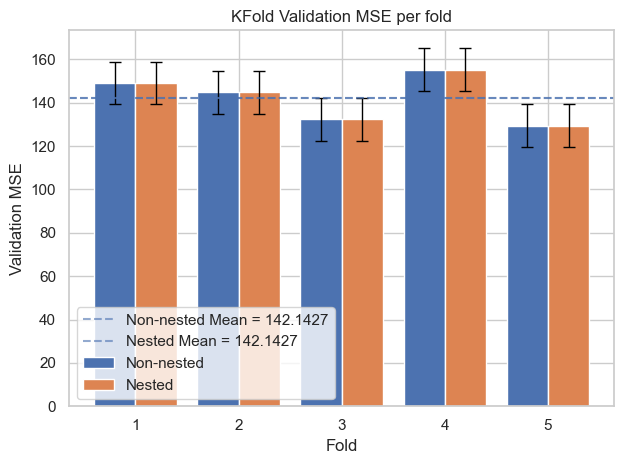

In [18]:
importlib.reload(cr)
cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], "mse")

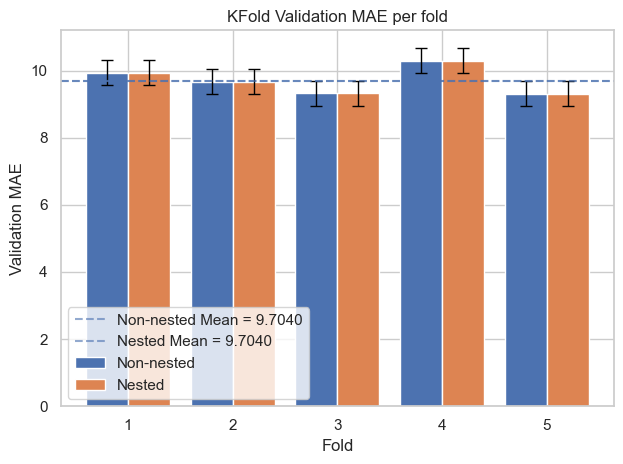

In [19]:
cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], "mae")

<h2>Test predictions</h2>
<hr/>

In [20]:
unfitted_model = runner.new_model()
fitted_model = runner.fit(unfitted_model, X_tr, y_tr)
y_pred = runner.predict(fitted_model, X_ts)

print(y_pred)

[[ -2.8605893   -1.6246365    5.5847077   -9.578887  ]
 [  8.547583     3.8661494  -32.886086    21.286928  ]
 [ -0.79529536  -0.06721447  -4.639972     5.991876  ]
 ...
 [  2.5523295    5.1049857   15.601646   -12.837318  ]
 [ 14.528483    -2.0755997  -22.337387    22.838285  ]
 [ -1.6260127   -0.34192556   4.7474556   -8.272153  ]]
